# Pure ConvTran Ultra-Fast Mode

This version is optimized for maximum speed:
- **Epochs**: 3
- **Training Data**: Capped at 250 samples per class (1000 total).
- **Validation Data**: Capped at 100 samples per class (400 total) to prevent long wait times.
- **Stability**: Lowered LR (5e-5) and standardized float32 (No AMP).

In [6]:
import os, sys, gc, logging, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

# Basic setup & Paths
PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'ConvTran'))

from src.utils import SEED, set_global_seed
from src.utils.paths import ensure_dir, get_experiment_dir, get_experiment_output_dir
from src.data import CLASS_NAMES, load_labels, load_raw_dataset, normalize_per_sample
from src.data.splits import load_splits
from src.training.evaluation import compute_metrics
from Models.model import model_factory

logging.basicConfig(level=logging.INFO)
NUM_CLASSES = len(CLASS_NAMES)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
# 1. Load & Subsample Data
idx_train_orig, idx_val_orig, idx_test = load_splits()
X_full, y_full = load_raw_dataset()
y_idx = np.argmax(y_full, axis=1) if y_full.ndim == 2 else y_full

print("Cleaning & Normalizing data...")
X_full = np.nan_to_num(X_full)
X_full = normalize_per_sample(X_full, axis=-1)
X_full = np.nan_to_num(X_full)

def subsample(indices, samples_per_class):
    X_sub = X_full[indices]
    y_sub = y_idx[indices]
    counts = Counter(y_sub)
    min_size = min(min(counts.values()), samples_per_class)
    
    final_idx = []
    np.random.seed(SEED)
    for cls in range(NUM_CLASSES):
        cls_map = np.where(y_sub == cls)[0]
        final_idx.extend(np.random.choice(cls_map, min_size, replace=False))
    np.random.shuffle(final_idx)
    return X_sub[final_idx], y_sub[final_idx]

print("Subsampling Train (250/class) and Val (100/class) for speed...")
X_train, y_train = subsample(idx_train_orig, 250)
X_val, y_val = subsample(idx_val_orig, 100)
X_test, y_test = X_full[idx_test], y_idx[idx_test]

print(f"Final Shapes: Train={X_train.shape}, Val={X_val.shape}")

INFO:src.data.io:Loaded cached dataset C:\Users\hmanasi1\Documents\deeplearning\Deep-Learning-Project\data\processed\chapman_wfdb_Xy.npz | X=(45150, 12, 5000) y=(45150, 4) | 32.41s


Cleaning & Normalizing data...
Subsampling Train (250/class) and Val (100/class) for speed...
Final Shapes: Train=(1000, 12, 5000), Val=(236, 12, 5000)


In [8]:
# 2. Stable Config
set_global_seed(SEED)
cond_name = "Pure_ConvTran_UltraFast"
exp_dir = ensure_dir(get_experiment_dir(cond_name))
ckpt_dir = ensure_dir(get_experiment_output_dir(cond_name, checkpoints=True))
ckpt_path = ckpt_dir / "model.pt"
history_path = ckpt_dir / "history.json"

config = {
    'Net_Type': ['C-T'], 'emb_size': 16, 'dim_ff': 256, 'num_heads': 8,
    'Fix_pos_encode': 'tAPE', 'Rel_pos_encode': 'eRPE', 'dropout': 0.1,
    'Data_shape': X_train.shape, 'num_labels': NUM_CLASSES
}
model = model_factory(config).to(device)
LR, BATCH_SIZE, EPOCHS, PATIENCE = 5e-5, 8, 20, 3
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

history = {'train_loss': [], 'val_f1': []}
best_val_f1 = -1
best_wts = copy.deepcopy(model.state_dict())

INFO:src.utils.seed:Global seed set to 0


In [9]:
# 3. Training/Val Loops
try:
    for ep in range(EPOCHS):
        model.train()
        loss_sum, nb = 0, 0
        pbar = tqdm(range(0, len(X_train), BATCH_SIZE), desc=f"Ep {ep+1} [Train]")
        for start in pbar:
            bx = torch.from_numpy(X_train[start:start+BATCH_SIZE]).float().to(device)
            by = torch.from_numpy(y_train[start:start+BATCH_SIZE]).long().to(device)
            
            opt.zero_grad()
            loss = F.cross_entropy(model(bx), by)
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=4.0)
            opt.step()
            
            loss_sum += loss.item(); nb += 1
            pbar.set_postfix(loss=loss_sum/nb)

        model.eval()
        preds = []
        v_bar = tqdm(range(0, len(X_val), 16), desc=f"Ep {ep+1} [Val]", leave=False)
        with torch.no_grad():
            for v in v_bar:
                bv = torch.from_numpy(X_val[v:v+16]).float().to(device)
                preds.append(model(bv).argmax(1).cpu().numpy())
        
        f1 = float(compute_metrics(y_val, np.concatenate(preds), task='multiclass', labels=list(range(NUM_CLASSES)))['weighted_f1'])
        history['train_loss'].append(float(loss_sum/nb))
        history['val_f1'].append(f1)
        print(f"  -> Val F1: {f1:.4f}")
        
        if f1 > best_val_f1:
            best_val_f1, best_wts = f1, copy.deepcopy(model.state_dict())
            torch.save({'epoch': ep, 'model_state': model.state_dict(), 'best_val_f1': best_val_f1}, ckpt_path)
finally:
    model.load_state_dict(best_wts)
    with open(history_path, 'w') as f: json.dump(history, f, indent=2)
    torch.cuda.empty_cache(); gc.collect()

Ep 1 [Train]: 100%|███████████████████████████████████████████████████████| 125/125 [14:26<00:00,  6.93s/it, loss=1.38]
                                                                                                                       

  -> Val F1: 0.2474


Ep 2 [Train]: 100%|███████████████████████████████████████████████████████| 125/125 [14:10<00:00,  6.81s/it, loss=1.35]
                                                                                                                       

  -> Val F1: 0.2841


Ep 3 [Train]: 100%|███████████████████████████████████████████████████████| 125/125 [14:10<00:00,  6.81s/it, loss=1.32]
                                                                                                                       

...

  -> Val F1: 0.6550


Ep 19 [Train]: 100%|█████████████████████████████████████████████████████| 125/125 [14:10<00:00,  6.81s/it, loss=0.857]
                                                                                                                       

  -> Val F1: 0.6382


Ep 20 [Train]: 100%|█████████████████████████████████████████████████████| 125/125 [14:10<00:00,  6.81s/it, loss=0.848]
                                                                                                                       

  -> Val F1: 0.6369


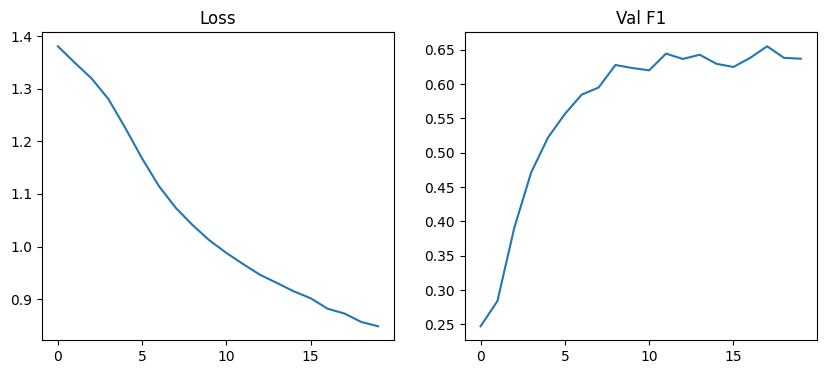

Final Testing...

Test F1: 0.6164


In [10]:
# 4. Plot & Final Test
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history['train_loss']); plt.title('Loss')
plt.subplot(1, 2, 2); plt.plot(history['val_f1']); plt.title('Val F1')
plt.show()

print("Final Testing...")
model.eval()
preds_ts = []
with torch.no_grad():
    for t in range(0, len(X_test), 16):
        bt = torch.from_numpy(X_test[t:t+16]).float().to(device)
        preds_ts.append(model(bt).argmax(1).cpu().numpy())
ts_mets = compute_metrics(y_test, np.concatenate(preds_ts), task='multiclass', labels=list(range(NUM_CLASSES)))
print("\nTest F1: %.4f" % ts_mets['weighted_f1'])
with open(exp_dir / 'final_metrics.json', 'w') as f:
    json.dump({k: float(v) if not isinstance(v, (dict, list, str)) else v for k,v in ts_mets.items()}, f, indent=2)